In [1]:
import numpy as np
import pandas as pd 
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.utils import image_dataset_from_directory
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os
import zipfile
print(os.listdir("../input"))
!pip install timm
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

2026-05-08 23:31:55.862669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778283116.096854      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778283116.162368      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778283116.707491      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778283116.707530      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778283116.707533      22 computation_placer.cc:177] computation placer alr

['datasets']


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = '/kaggle/input/datasets/mahmoudreda55/satellite-image-classification/data'

In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root = data_dir, transform=transform)
class_names = full_dataset.classes
n_classes = len(class_names)

In [4]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

In [5]:
class SatelliteViT(nn.Module):
    def __init__(self, n_classes):
        super(SatelliteViT, self).__init__()
        self.model = timm.create_model('vit_tiny_patch16_224', pretrained = True)
        n_features = self.model.head.in_features
        self.model.head = nn.Linear(n_features, n_classes)

    def forward(self, x):
        return self.model(x)

model = SatelliteViT(n_classes).to(device)

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr = 1e-4, weight_decay = 1e-2)


In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)
    return running_loss / len(loader.dataset), correct.double() / len(loader.dataset)



In [8]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
    return running_loss / len(loader.dataset), correct.double() / len(loader.dataset)

In [9]:
epochs = 10
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}")

Epoch 1/10 | Train Acc: 0.9785 | Val Acc: 0.9973 | Val Loss: 0.0049
Epoch 2/10 | Train Acc: 0.9969 | Val Acc: 0.9991 | Val Loss: 0.0016
Epoch 3/10 | Train Acc: 1.0000 | Val Acc: 0.9991 | Val Loss: 0.0017
Epoch 4/10 | Train Acc: 0.9889 | Val Acc: 0.9876 | Val Loss: 0.0388
Epoch 5/10 | Train Acc: 0.9936 | Val Acc: 0.9894 | Val Loss: 0.0374
Epoch 6/10 | Train Acc: 0.9989 | Val Acc: 0.9973 | Val Loss: 0.0144
Epoch 7/10 | Train Acc: 0.9987 | Val Acc: 1.0000 | Val Loss: 0.0008
Epoch 8/10 | Train Acc: 0.9989 | Val Acc: 1.0000 | Val Loss: 0.0006
Epoch 9/10 | Train Acc: 1.0000 | Val Acc: 0.9991 | Val Loss: 0.0023
Epoch 10/10 | Train Acc: 1.0000 | Val Acc: 1.0000 | Val Loss: 0.0004


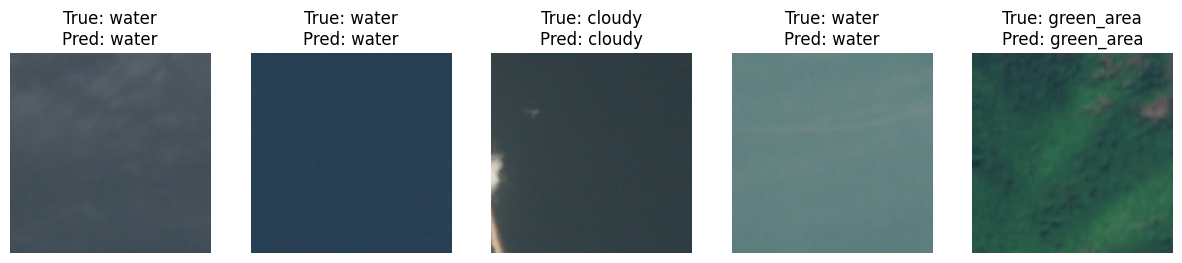

In [10]:
def visualize_results(model, dataset, device, n=5):
    model.eval()
    plt.figure(figsize=(15, 5))
    for i in range(n):
        idx = torch.randint(0, len(dataset), (1,)).item()
        img_tensor, label = dataset[idx]
        with torch.no_grad():
            output = model(img_tensor.unsqueeze(0).to(device))
            pred = torch.argmax(output, dim=1).item()
            
        img_show = img_tensor.permute(1, 2, 0).numpy()
        img_show = img_show * [0.229, 0.224, 0.225]+[0.485, 0.456, 0.406]
        
        plt.subplot(1, n, i+1)
        plt.imshow(img_show.clip(0, 1))
        plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
        plt.axis('off')
    plt.show()

visualize_results(model, val_dataset, device)